In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import xarray as xr
import numpy as np
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 
import xbudget
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2025.10.1
xgcm: 0.9.0


In [42]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

In [43]:
ecco_budget = xr.open_mfdataset("../data/data/ECCO_budget_terms.zarr")
dt = ecco_budget["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})

ecco_budget = ecco_budget.assign_coords(
    {"dt":("time", dt.dt.total_seconds().values), 
    "volcello": (ecco_budget["drF"] * ecco_budget["hFacC"]) * ecco_budget["rA"]
    }
)

ecco_budget["WVELMASS_interior"] = zero_top_layer(ecco_budget, varname = "WVELMASS", zdim = "k_l")
ecco_budget["oceFWflx_3d"] = make_flux_3d(ecco_budget, varname = "oceFWflx", zdim = "k")

ecco_budget = ecco_budget.chunk({"k_l":-1, "tile":-1, "time_bounds":-1, "time":-1})

ecco_budget = ecco_budget.fillna(0.0)

#to-do: need to add a chunking line in the difference and convergence sections of the code 

In [60]:
grid = construct_grid(ecco_budget)
xbudget_dict = xbudget.load_yaml("ECCOV4r4.yaml").copy()
xbudget.collect_budgets(grid, xbudget_dict)
simple_budgets = xbudget.aggregate(xbudget_dict)
simple_budgets

{'mass': {'lambda': 'density',
  'thickness': 'thkcello',
  'lhs': {'Eulerian_tendency': 'mass_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'mass_rhs_sum_advection',
   'surface_exchange_flux': 'mass_rhs_sum_surface_exchange_flux'}},
 'heat': {'lambda': 'THETA',
  'lhs': {'Eulerian_tendency': 'heat_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'heat_rhs_sum_advection',
   'diffusion': 'heat_rhs_sum_diffusion',
   'surface_exchange_flux': 'heat_rhs_sum_surface_exchange_flux',
   'bottom_flux': 'heat_rhs_sum_bottom_flux'}}}

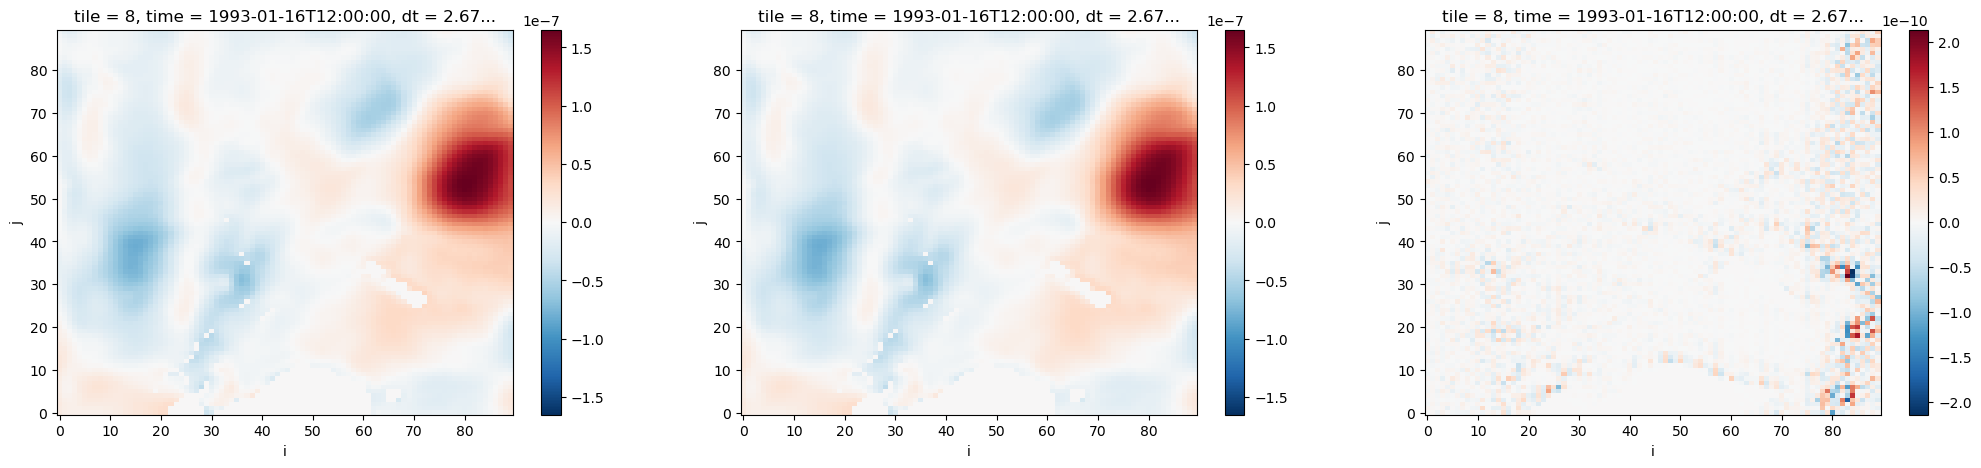

In [61]:
fig, ax = plt.subplots(1,3, figsize = (25, 5))
lhs_tendency = grid._ds[xbudget.get_vars(xbudget_dict, "mass_lhs")['var']]
lhs_tendency = lhs_tendency / (lhs_tendency.rA  * 1029.00 )
lhs_tendency.isel(time = 0, tile = 8).sum("k").plot(ax = ax[0])

rhs_tendency = grid._ds[xbudget.get_vars(xbudget_dict, "mass_rhs_sum")['var']]
rhs_tendency = rhs_tendency / (rhs_tendency.rA  * 1029.00)
rhs_tendency.isel(time = 0, tile = 8).sum("k").plot(ax = ax[1])


(lhs_tendency - rhs_tendency).sum("k").isel(time = 0, tile = 8).plot(ax = ax[2])

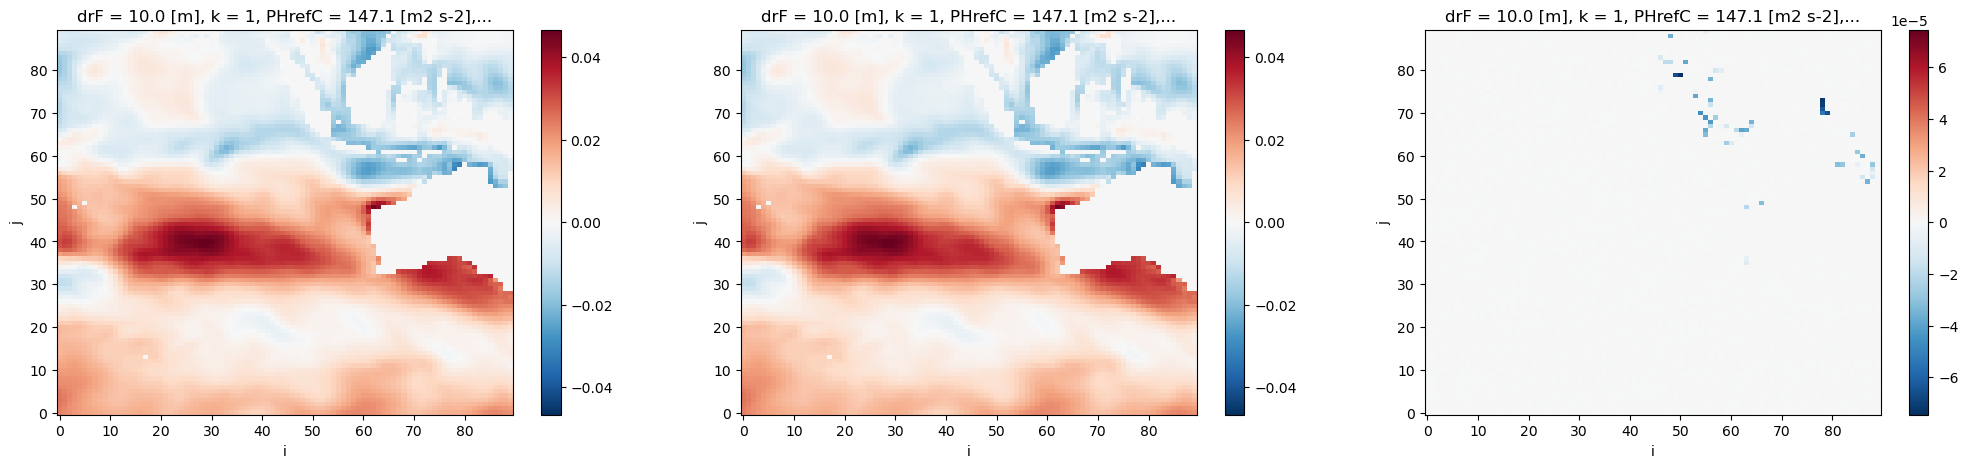

In [62]:
k = 1
fig, ax = plt.subplots(1,3, figsize = (25, 5))
lhs_tendency = grid._ds[xbudget.get_vars(xbudget_dict, "heat_lhs")['var']]
lhs_tendency = lhs_tendency / (lhs_tendency.rA  * 1029.00 )
lhs_tendency.isel(time = 0, tile = 4, k = k).plot(ax = ax[0])

rhs_tendency = grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs_sum")['var']]
rhs_tendency = rhs_tendency / (rhs_tendency.rA  * 1029.00)
rhs_tendency.isel(time = 0, tile = 4, k = k).plot(ax = ax[1])

(lhs_tendency - rhs_tendency).isel(time = 0, tile = 4, k = k).plot(ax = ax[2])